# Data Disaggregation


When we look at data, we often start with an overall summary — one average, one trend line, one distribution. But real-world data rarely come from a single, uniform process. Different groups or conditions can behave very differently, and lumping them together can hide important patterns.

**Disaggregation** means describing or plotting data separately for meaningful subgroups. For example, by gender, age, region, experimental condition, etc.

As we saw in the first lecture of the series, data within a single dataset can arise from different underlying processes, for example:

* The distribution of *age at death* in 1840 includes several distinct causes, including: deaths caused by infant/child mortality and deaths due to old age
* The average exam score across years may be is 65 but that might hide the fact that one year averaged 75 and another averaged 55.
* The distribution of reaction times in a psychological experiment may include a mixture of *true* responses, *false starts*, and *missed trials*

<hr style="border:0.5px solid #cccccc; margin: 10px 0;">


Disaggregating data so that we are reporting statistics separately for these different groups is an important part of describing and analyzing data. For example:

* if we would like to report the mean reaction time for each condition of our psychological experiment based only on 'true' responses, that is, exclusing missed trials.


Disaggregation becomes even more important when we move towards making predictions based on data. For example:

* If a patient presents with chest pain, is it more likely to be indigestion or a heart attack? The answer to this question partly depends on the `AGE` of the patient (heart attacks are much less likely in young patients), BUT that is different again for men and women.


#### Equality

If a dataset includes a majority and minority group (for example, if the dataset consistes of more men than women, or more white people than black people), then failure to disaggregate data results in findings being biased towards the majority group

* For example, shockingly, <a href="https://www.theguardian.com/society/2021/nov/11/black-women-uk-maternal-mortality-rates">black women are four times more likely to die in childbirth</a> than white women in the UK, a statistic that was long un-remarked because data on maternal outcomes were not routinely disaggregated by race. 

    
#### Disaggregation skills
    
Working out  which categories of data should be presented in disaggretgated form is a skill that you will learn through practice. Too little disaggregation can obscure important group differences or retains noise that could be removed; but too much disaggregation can result in an ocean of graphs and statistics that makes it hard to see the big picture.

In this section we will look at disaggregation in the context of the heart attack dataset.    


**Here is a video about disaggregating data:**


In [2]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/xmsm_wQmRI4?si=B6f8LTSjp3UifvNG" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

### Set up Python Libraries

As usual you will need to run this code block to import the relevant Python libraries

In [3]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Import a dataset to work with

Let's continue with the NYC heart attack dataset:

In [9]:
hospital=pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_resources/main/data/heartAttack.csv')
display(hospital)


,CHARGES,LOS,AGE,SEX,DRG,DIED
0,4752.00,10,79.0,F,122.0,0.0
1,3941.00,6,34.0,F,122.0,0.0
2,3657.00,5,76.0,F,122.0,0.0
3,1481.00,2,80.0,F,122.0,0.0
4,1681.00,1,55.0,M,122.0,0.0
...,...,...,...,...,...,...
12839,22603.57,14,79.0,F,121.0,0.0
12840,NaN,7,91.0,F,121.0,0.0
12841,14359.14,9,79.0,F,121.0,0.0
12842,12986.00,5,70.0,M,121.0,0.0


#### Clean the data

We have reloaded the dataframe from the .csv file, so we need to re-implement the data cleaning steps we already decided were necessary: 

*Note, since we found `9999` is a dummy value for multiple columns, you can use the `.replace()` function on the entire dataset, being sure to replace the exisiting dataset.*

In [10]:
hospital = hospital.replace(9999, np.nan)
hospital.describe() # check it worked

,CHARGES,LOS,AGE,DRG,DIED
count,12145.000000,12843.000000,12840.000000,12841.000000,12841.000000
mean,9879.087615,7.567858,66.288162,121.690523,0.109805
std,6558.399650,5.114357,13.654237,0.658289,0.312658
min,3.000000,0.000000,20.000000,121.000000,0.000000
25%,5422.200000,4.000000,57.000000,121.000000,0.000000
50%,8445.000000,7.000000,67.000000,122.000000,0.000000
75%,12569.040000,10.000000,77.000000,122.000000,0.000000
max,47910.120000,38.000000,103.000000,123.000000,1.000000


## Age vs Sex

Let's start by looking at the age distribution of our dataset. By now we have removed the outliers so we should see a relatively normal looking distribution. 

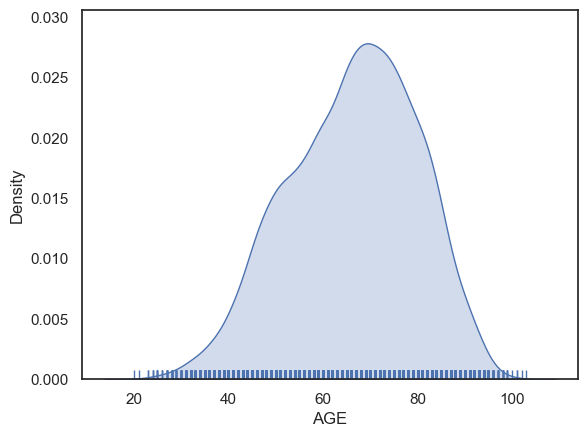

In [14]:
sns.kdeplot(data=hospital, x='AGE', fill=True) 
sns.rugplot(data = hospital, x ='AGE')
plt.show()

We might wonder whether the age distribution of heart attack patients the same regardless of sex? That is, do men and women tend to experience heart attacks at similar ages, or are there noticeable differences between the groups?


Let's find out by plotting the age distribution separately for men and women. To do this we will simply make use of the `hue` argument in the seaborn plots: 

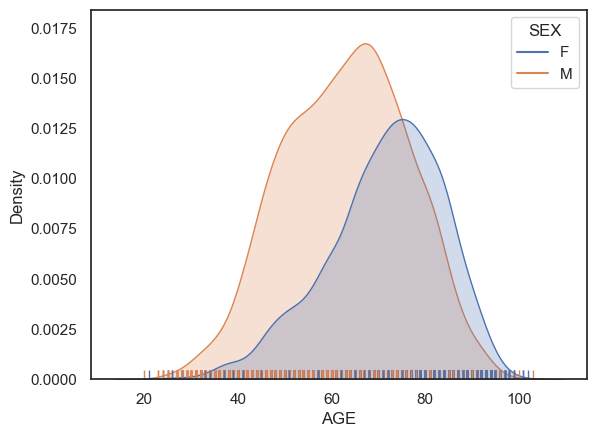

In [18]:
sns.kdeplot(data=hospital, x='AGE', hue='SEX', fill=True) 
sns.rugplot(data = hospital, hue = 'SEX', x ='AGE')

plt.show()

**Note-**
* Overall, more men had heart attacks than women
* The female patients tend to be older.

**Think**

A 40 year old patient presents with chest pain. It could be a heart attack or it could be indigestion. The doctor needs to decide the likely cause. Does it matter whether the patient is a man or a woman?

### Length of stay vs. Mortality

Let's plot the distribution of Length of Stay in hospital:

*Note: here we are plotting using a histogram with an overlaid kde, where as above we used a kde plot in combination with a rug plot. All this to say, there's more than one way to plot a distribution!* 

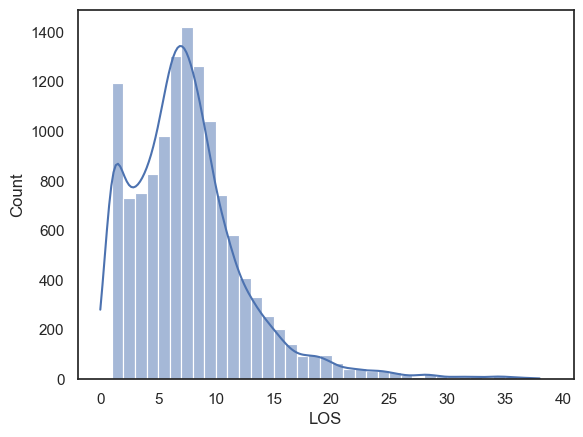

In [19]:
sns.histplot(data=hospital, x='LOS', bins=range(0,40), kde = True)
plt.show()

You may notice something slightly unusual in the distribution. The data seems *bimodal*, meaing there are two peaks in the distribution. In this case, we see a large number of people staying just one day in hospital, with another group staying a bit longer. 

A bimodal distribution often suggests that the data are actually a mixture of two underlying populations each with its own distinct distribution. In other words, we suspect the length of stay data could be meaningfully *disaggregated*.

If we disaggregate these by the categorical variable <tt>DIED</tt>, we can get a clearer picture what happened:


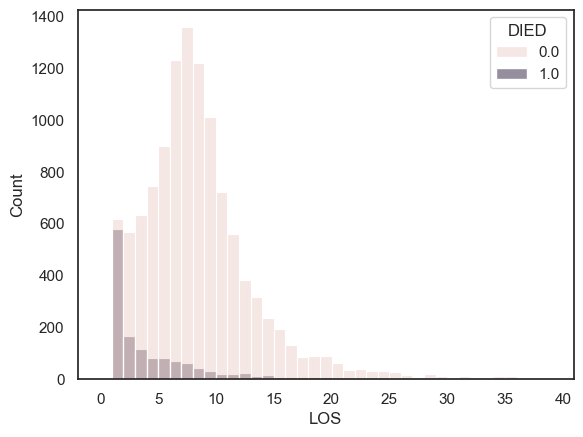

In [6]:
sns.histplot(data=hospital, x='LOS', hue='DIED', bins=range(0,40))
plt.show()

What you see above is that people who died from their heart attack tended to have short stays in hosiptal, with many dying on the same day they were admitted. In contrast, those who survived, typically stayed in the hospital for 7-10 days.

## Mortality vs Sex

Let's consider the mortality (`DIED`) as a dependent variable. Using `sns.barplot()` we can get initial look at how mortality rate differs by sex. At first glance, it appears female patients are much more likely to die than males:

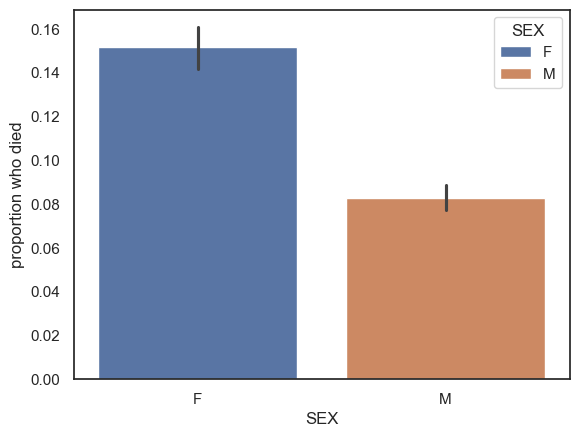

In [22]:
sns.barplot(data=hospital, y='DIED', x='SEX', hue = 'SEX')
plt.ylabel('proportion who died')
plt.show()

Is the apparent difference in mortality between the sexes due to differences in the severity of the heart attacks, or perhaps differences in the effectiveness of treatment?

Probably not. 

We noticed earlier that the female patients tended to be *older* than the males, so it is reasonable to wonder whether `AGE` might play a role in survival. 

It turns out this is true, younger patients are more likely to survive. We can see this clearly by plotting the proportion who patients who died at each age. 

*Note, the error bars (shading around the line) becomes larger at the very high and very low ages because we do not have many data points at the extremes*

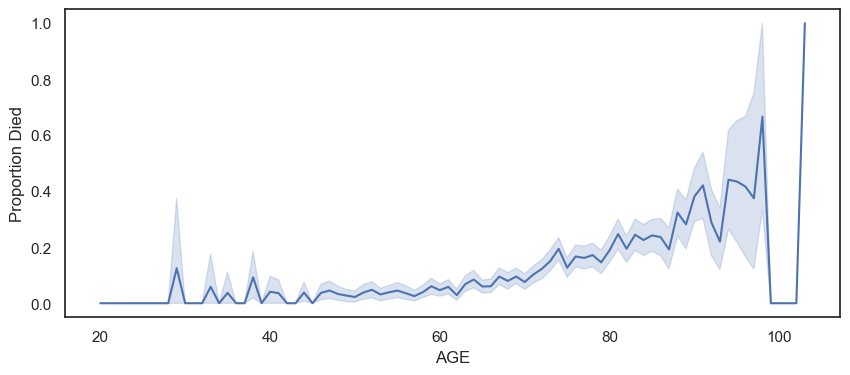

In [31]:
plt.figure(figsize=(10,4))

sns.lineplot(data = hospital, x = 'AGE', y = 'DIED')
plt.ylabel('Proportion Died')
plt.show()

Now let's try disaggregating the sexes from age. By, plotting the data like this make it clear that `AGE` is a much stronger predictor of mortality compared to `SEX`

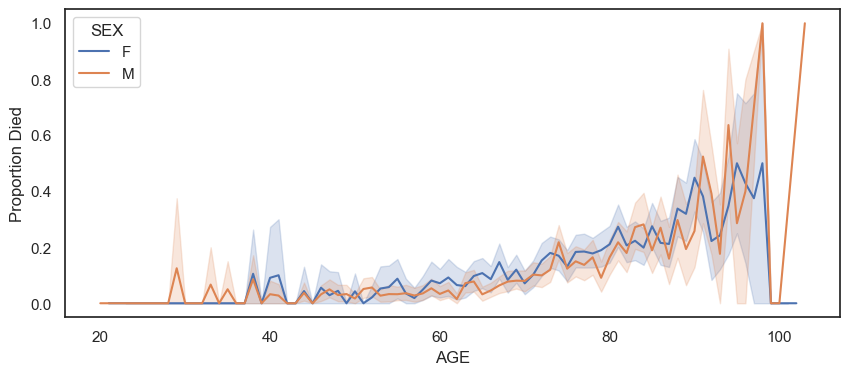

In [35]:
plt.figure(figsize=(10,4))

sns.lineplot(data = hospital, x = 'AGE', hue = 'SEX', y = 'DIED')
plt.ylabel('Proportion Died')
plt.show()

### Conclusion

You can learn a lot by disaggregating data! Breaking data down into meaningful subgroups often reveals hidden patterns and distinct underlying processes that would otherwise be lost in the overall averages.

This process of exploring, comparing, and interpreting differences between groups lies at the heart of what a good data scientist (or any research scientist) does. It’s how we move beyond describing data to truly understanding the relationships and mechanisms that generate it.
